# Basic Image Classification w/ Keras

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Classify images of Clothing

## Dataset Fetch & Load

In [2]:
fashion_minst = tf.keras.datasets.fashion_mnist

In [3]:
(raw_train_images, train_labels), (raw_test_images, test_labels) = fashion_minst.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [4]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

### Training Dataset - EDA

In [5]:
raw_train_images.shape

(60000, 28, 28)

In [6]:
set(train_labels)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

### Test Dataset - EDA

In [7]:
raw_test_images.shape

(10000, 28, 28)

In [8]:
set(test_labels)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

## Dataset Preprocessing

In [9]:
def plot(image):
    plt.figure()
    plt.imshow(image)
    plt.colorbar()
    plt.grid(False)
    plt.show()

In [10]:
def multi_plot(images, labels, classes):
    plt.figure(figsize=(10,10))
    
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(classes[labels[i]])

    plt.show()

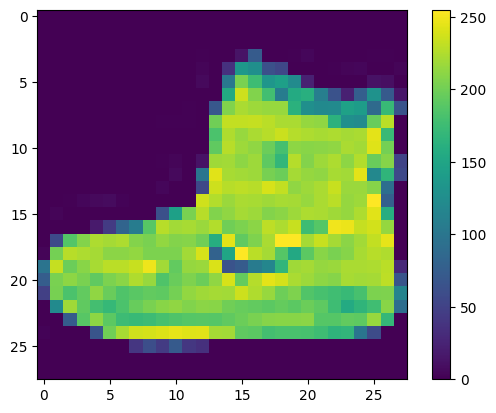

In [11]:
plot(image=raw_train_images[0])

In [12]:
train_images = raw_train_images / 255.0
test_images = raw_test_images / 255.0

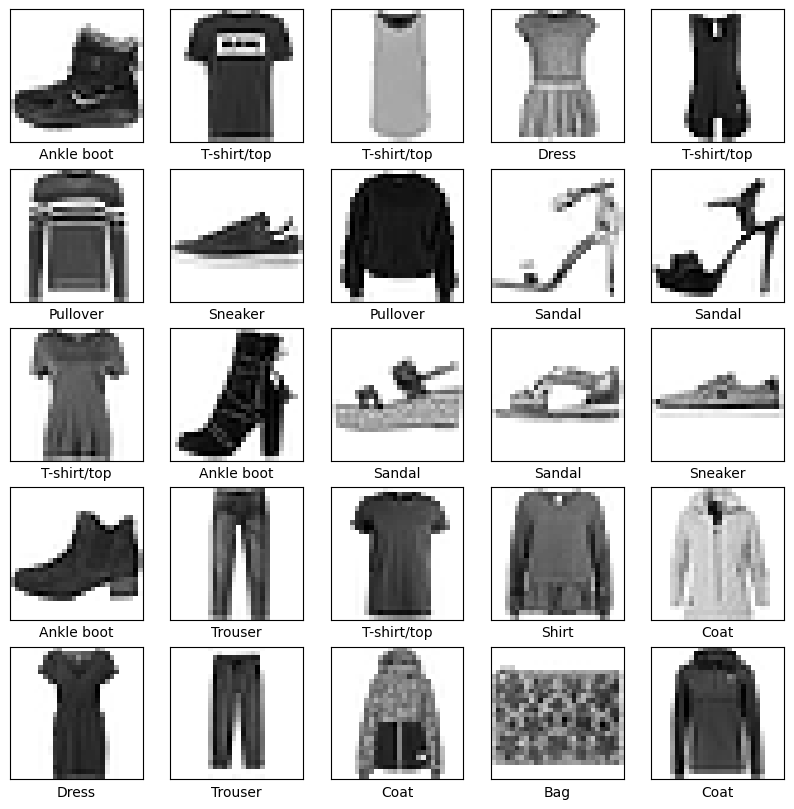

In [14]:
multi_plot(images=train_images, labels=train_labels, classes=class_names)

## Model Training

### Layers Setup

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

2024-01-27 02:45:13.733706: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2024-01-27 02:45:13.733730: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2024-01-27 02:45:13.733737: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2024-01-27 02:45:13.733800: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-27 02:45:13.733846: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Model Compilation

In [16]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

### Model Training

In [18]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10


2024-01-27 02:45:23.042346: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 [==============================] - 11s 5ms/step - loss: 0.5469 - accuracy: 0.8102
Epoch 2/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4702 - accuracy: 0.8369
Epoch 3/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4641 - accuracy: 0.8403
Epoch 4/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4690 - accuracy: 0.8394
Epoch 5/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4680 - accuracy: 0.8417
Epoch 6/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4727 - accuracy: 0.8410
Epoch 7/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4729 - accuracy: 0.8410
Epoch 8/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4851 - accuracy: 0.8390
Epoch 9/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4885 - accuracy: 0.8367
Epoch 10/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.5034 - accura

### Model Evaluation

In [19]:
test_loss, test_accuracy = model.evaluate(test_images,  test_labels, verbose=2)

313/313 - 1s - loss: 0.5568 - accuracy: 0.8234 - 1s/epoch - 4ms/step


In [20]:
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Test Loss: 0.5567971467971802
Test Accuracy: 0.8234000205993652


## Model Inference

In [21]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

In [22]:
predictions = probability_model.predict(test_images)

313/313 [==============================] - 0s 1ms/step


In [23]:
predictions[0]

array([2.26670793e-09, 1.74321115e-12, 1.38542123e-06, 1.60712188e-09,
       4.61831945e-07, 1.14570424e-01, 2.56593353e-07, 4.61509526e-02,
       4.10730921e-04, 8.38865817e-01], dtype=float32)

In [24]:
np.argmax(predictions[0])

9

In [25]:
test_labels[0]

9

### Setting up ground work

In [26]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

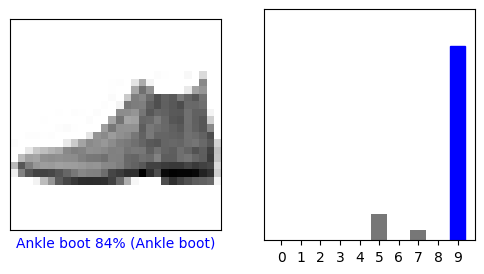

In [27]:
i = 0

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

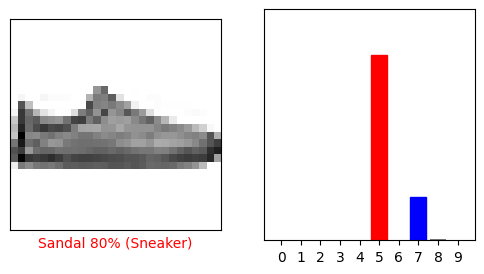

In [28]:
i = 12

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

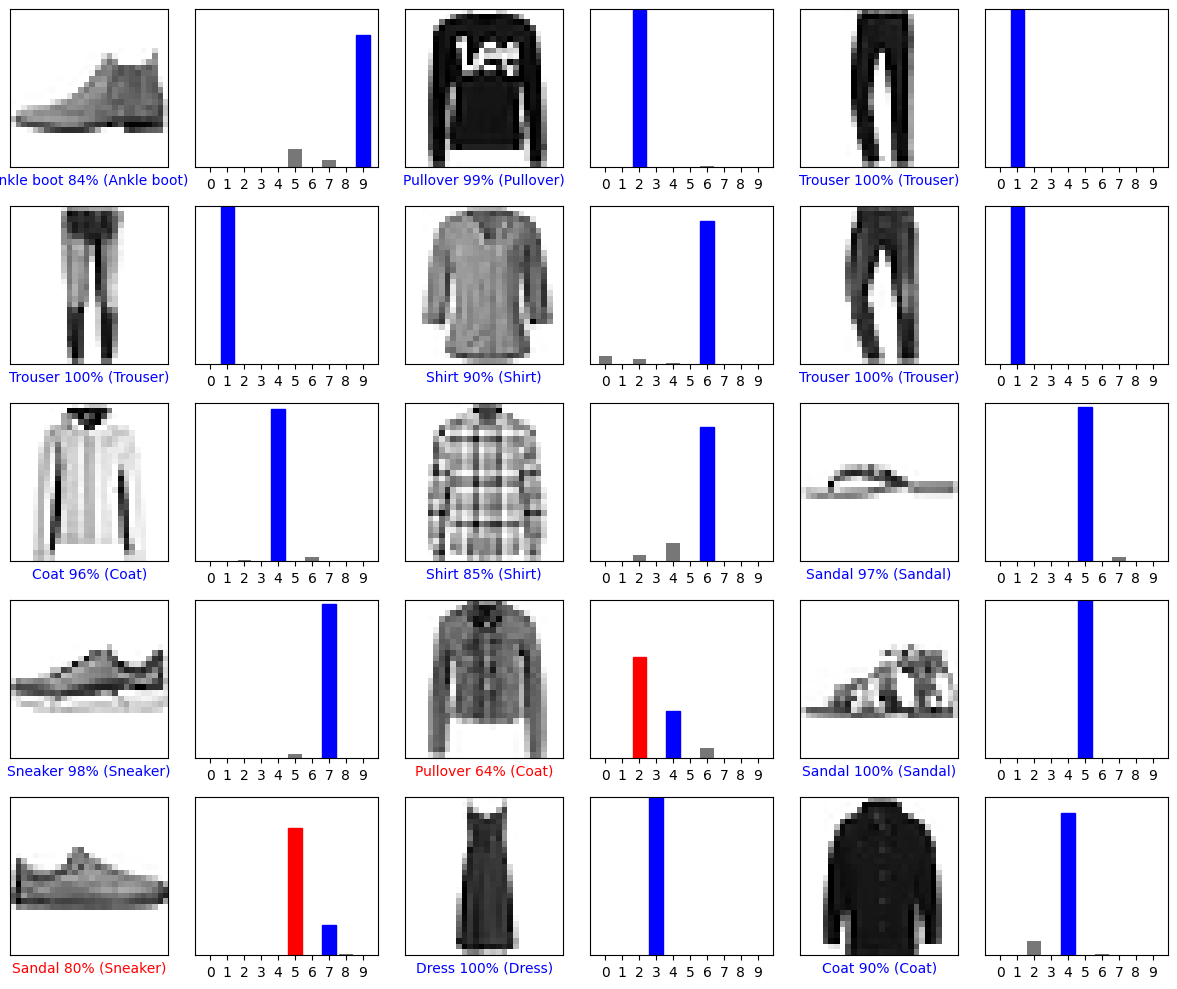

In [29]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols

plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
    
plt.tight_layout()
plt.show()